# 03 - Modélisation

**Objectif** : Entraîner 3 modèles + 1 ensemble pour prédire le rendement agricole (t/ha)

| # | Modèle | Description |
|---|--------|-------------|
| 1 | Random Forest | 300 arbres indépendants — baseline robuste |
| 2 | XGBoost | 500 arbres séquentiels — modèle principal |
| 3 | CNN-LSTM | Réseau de neurones — patterns complexes |
| 4 | Ensemble (Stacking) | Combine les 3 avec un méta-modèle |

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Chargement des données

In [12]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
feature_cols = joblib.load('../models/feature_cols.joblib')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

Train: (4800, 27) | Test: (1200, 27)
Features: 27


In [13]:
def evaluate(mdl, name, X_tr, X_te, y_tr, y_te):
    y_pred_train = mdl.predict(X_tr)
    y_pred_test = mdl.predict(X_te)
    y_te_real = np.expm1(y_te)
    y_pred_real = np.expm1(y_pred_test)

    results = {
        'name': name,
        'r2_train': r2_score(y_tr, y_pred_train),
        'r2_real': r2_score(y_te_real, y_pred_real),
        'rmse_real': np.sqrt(mean_squared_error(y_te_real, y_pred_real)),
        'mae_real': mean_absolute_error(y_te_real, y_pred_real)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train R²: {results['r2_train']:.4f}")
    print(f"  Test  R²: {results['r2_real']:.4f}")
    print(f"  RMSE: {results['rmse_real']:.2f} t/ha")
    print(f"  MAE:  {results['mae_real']:.2f} t/ha")

    return results, y_pred_real

## 2. Random Forest

In [14]:
print("Entraînement Random Forest...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_results, rf_preds = evaluate(rf, "RANDOM FOREST", X_train, X_test, y_train, y_test)
print(f"  Temps: {time.time()-t0:.1f}s")

joblib.dump(rf, '../models/random_forest.joblib')

Entraînement Random Forest...

  RANDOM FOREST
  Train R²: 0.9814
  Test  R²: 0.8201
  RMSE: 2.96 t/ha
  MAE:  1.63 t/ha
  Temps: 10.3s


['../models/random_forest.joblib']

## 3. XGBoost

In [15]:
print("Entraînement XGBoost...")
t0 = time.time()

xgb = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_results, xgb_preds = evaluate(xgb, "XGBOOST", X_train, X_test, y_train, y_test)
print(f"  Temps: {time.time()-t0:.1f}s")

joblib.dump(xgb, '../models/xgboost.joblib')

Entraînement XGBoost...

  XGBOOST
  Train R²: 0.9996
  Test  R²: 0.8086
  RMSE: 3.05 t/ha
  MAE:  1.71 t/ha
  Temps: 11.8s


['../models/xgboost.joblib']

## 4. CNN-LSTM

In [16]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Conv1D, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    HAS_TF = True
    print(f"TensorFlow: {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow non disponible — CNN-LSTM ignoré")
    print("Installer avec: pip install tensorflow")

I0000 00:00:1780056183.825418 2870425 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780056183.889943 2870425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780056186.971505 2870425 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


In [17]:
if HAS_TF:
    n_features = X_train_scaled.shape[1]
    X_train_cnn = X_train_scaled.values.reshape(-1, n_features, 1)
    X_test_cnn = X_test_scaled.values.reshape(-1, n_features, 1)

    cnn_model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=(n_features, 1)),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    cnn_model.summary()
else:
    print("Ignoré")

E0000 00:00:1780056190.965658 2870425 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 27, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 27, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 27, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,033 (359.50 KB)

 Trainable params: 91,521 (357.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [18]:
if HAS_TF:
    print("Entraînement CNN-LSTM...")
    t0 = time.time()
    history = cnn_model.fit(
        X_train_cnn, y_train.values,
        validation_data=(X_test_cnn, y_test.values),
        epochs=150, batch_size=64,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
        ],
        verbose=1
    )
    print(f"\nTemps: {time.time()-t0:.1f}s | Époques: {len(history.history['loss'])}")
else:
    print("Ignoré")

Entraînement CNN-LSTM...
Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 1.5460 - mae: 0.9732 - val_loss: 2.0246 - val_mae: 1.0763 - learning_rate: 0.0010
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.8531 - mae: 0.7507 - val_loss: 1.6491 - val_mae: 0.9477 - learning_rate: 0.0010
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.7944 - mae: 0.7264 - val_loss: 1.2747 - val_mae: 0.8581 - learning_rate: 0.0010
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.7185 - mae: 0.6906 - val_loss: 1.3373 - val_mae: 0.8741 - learning_rate: 0.0010
Epoch 5/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.6754 - mae: 0.6645 - val_loss: 0.9265 - val_mae: 0.7701 - learning_rate: 0.0010
Epoch 6/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.6287 - mae: 0.6351 - val_loss: 0.6939 - val_mae: 0.6528 - learning_rate: 0.0010
Epoch 7/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.5707 - mae: 0.6026 - val_loss: 0.6327 - val_mae: 0.6277 - le

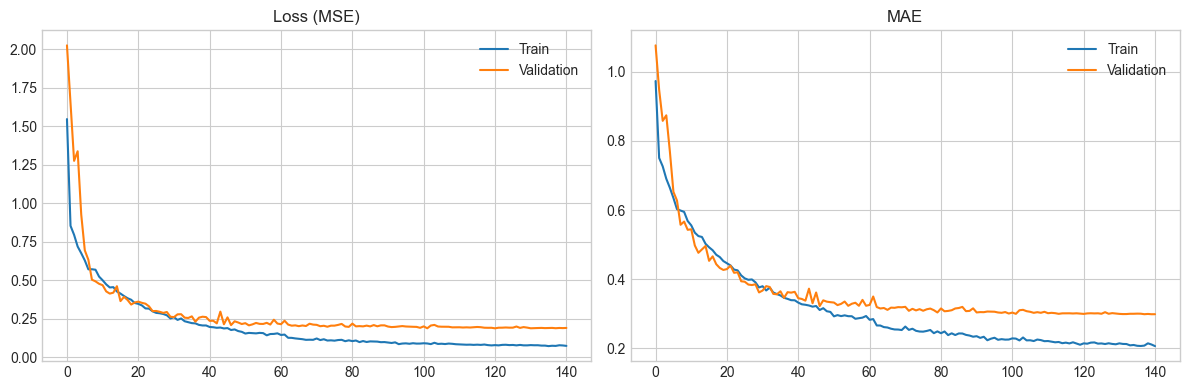

CNN-LSTM — R²: 0.7192 | RMSE: 3.70 | MAE: 2.14


In [19]:
if HAS_TF:
    # Courbes d'apprentissage
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title('Loss (MSE)'); axes[0].legend()
    axes[1].plot(history.history['mae'], label='Train')
    axes[1].plot(history.history['val_mae'], label='Validation')
    axes[1].set_title('MAE'); axes[1].legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/cnn_lstm_training.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Évaluation
    y_pred_cnn_log = cnn_model.predict(X_test_cnn, verbose=0).flatten()
    y_pred_cnn_real = np.expm1(y_pred_cnn_log)
    y_test_real = np.expm1(y_test)

    cnn_results = {
        'name': 'CNN-LSTM',
        'r2_real': r2_score(y_test_real, y_pred_cnn_real),
        'rmse_real': np.sqrt(mean_squared_error(y_test_real, y_pred_cnn_real)),
        'mae_real': mean_absolute_error(y_test_real, y_pred_cnn_real)
    }
    print(f"CNN-LSTM — R²: {cnn_results['r2_real']:.4f} | RMSE: {cnn_results['rmse_real']:.2f} | MAE: {cnn_results['mae_real']:.2f}")
    cnn_model.save('../models/cnn_lstm_model.keras')
else:
    cnn_results = None
    print("CNN-LSTM non disponible")

## 5. Feature Importance (XGBoost)

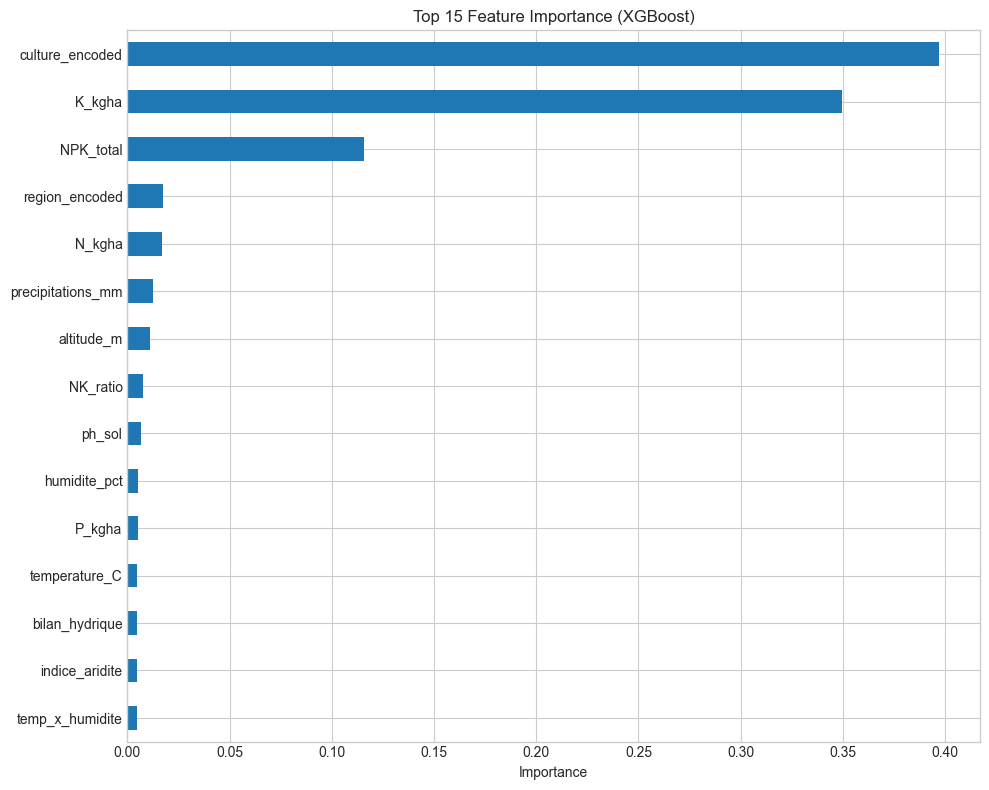

In [20]:
importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.tail(15).plot(kind='barh')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ensemble (Stacking)

On combine les prédictions des modèles avec un méta-modèle Ridge :
```
RF  ──→ pred_rf  ──┐
XGB ──→ pred_xgb ──├──→ Méta-modèle Ridge ──→ Prédiction finale
CNN ──→ pred_cnn ──┘
```

In [21]:
# Construire les prédictions de base
pred_rf_train = rf.predict(X_train)
pred_xgb_train = xgb.predict(X_train)
pred_rf_test = rf.predict(X_test)
pred_xgb_test = xgb.predict(X_test)

if HAS_TF and cnn_results:
    pred_cnn_train = cnn_model.predict(X_train_cnn, verbose=0).flatten()
    pred_cnn_test = cnn_model.predict(X_test_cnn, verbose=0).flatten()
    stack_train = np.column_stack([pred_rf_train, pred_xgb_train, pred_cnn_train])
    stack_test = np.column_stack([pred_rf_test, pred_xgb_test, pred_cnn_test])
    stacking_names = ['RF', 'XGBoost', 'CNN-LSTM']
else:
    stack_train = np.column_stack([pred_rf_train, pred_xgb_train])
    stack_test = np.column_stack([pred_rf_test, pred_xgb_test])
    stacking_names = ['RF', 'XGBoost']

# Méta-modèle
meta_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
meta_model.fit(stack_train, y_train)

y_pred_ensemble_log = meta_model.predict(stack_test)
y_pred_ensemble_real = np.expm1(y_pred_ensemble_log)
y_test_real = np.expm1(y_test)

ensemble_results = {
    'name': 'ENSEMBLE (Stacking)',
    'r2_real': r2_score(y_test_real, y_pred_ensemble_real),
    'rmse_real': np.sqrt(mean_squared_error(y_test_real, y_pred_ensemble_real)),
    'mae_real': mean_absolute_error(y_test_real, y_pred_ensemble_real)
}

print(f"{'='*50}")
print(f"  ENSEMBLE (Stacking)")
print(f"{'='*50}")
print(f"  R²: {ensemble_results['r2_real']:.4f}")
print(f"  RMSE: {ensemble_results['rmse_real']:.2f} t/ha")
print(f"  MAE:  {ensemble_results['mae_real']:.2f} t/ha")
print(f"\n  Poids:")
for name, coef in zip(stacking_names, meta_model.coef_):
    print(f"    {name}: {coef:.3f}")

joblib.dump(meta_model, '../models/meta_model_stacking.joblib')

  ENSEMBLE (Stacking)
  R²: 0.8063
  RMSE: 3.07 t/ha
  MAE:  1.72 t/ha

  Poids:
    RF: -0.100
    XGBoost: 1.114
    CNN-LSTM: -0.014


['../models/meta_model_stacking.joblib']

## 7. Comparaison finale

In [22]:
results_list = [rf_results, xgb_results]
if cnn_results:
    results_list.append(cnn_results)
results_list.append(ensemble_results)

all_results = pd.DataFrame(results_list)
all_results = all_results[['name', 'r2_real', 'rmse_real', 'mae_real']]
all_results.columns = ['Modèle', 'R²', 'RMSE (t/ha)', 'MAE (t/ha)']
all_results = all_results.sort_values('R²', ascending=False)

print("="*60)
print("  COMPARAISON FINALE")
print("="*60)
print(all_results.to_string(index=False))
print(f"\n  → Meilleur: {all_results.iloc[0]['Modèle']}")

  COMPARAISON FINALE
             Modèle       R²  RMSE (t/ha)  MAE (t/ha)
      RANDOM FOREST 0.820061     2.961261    1.632342
            XGBOOST 0.808631     3.053871    1.705230
ENSEMBLE (Stacking) 0.806330     3.072171    1.718905
           CNN-LSTM 0.719230     3.699046    2.135518

  → Meilleur: RANDOM FOREST


## Résumé

| Approche | Description |
|----------|-------------|
| **Random Forest** | 300 arbres indépendants, vote par moyenne |
| **XGBoost** | 500 arbres séquentiels, chaque arbre corrige le précédent |
| **CNN-LSTM** | CNN extrait patterns locaux, LSTM capture séquences |
| **Stacking** | Méta-modèle Ridge qui apprend le poids optimal de chacun |

**Prochaine étape** : API FastAPI pour servir les prédictions + recommandations